# trust-issues
### A LendingClub credit-risk model that did the boring parts right.

---

Most credit-risk portfolio projects fail quietly, in ways that never show up in a headline AUC. A target defined by hand from twenty loan-status categories. Post-decision fields — `recoveries`, `total_pymnt` — leaking future information into features. A random train/test split that lets the model peek at the future. An uncalibrated score optimized for a Kaggle metric that no one could actually price a loan with.

None of these are visible if you only look at the score. Some of them make the score *better*.

This project treats a low, honest AUC as the goal — not a high, contaminated one. It is built around a single discipline: **don't trust a number until you've tried to break it.**

---

**What that discipline looks like, section by section:**

| Stage | The question it refuses to answer with a shortcut |
|---|---|
| **Temporal split** | Would this hold up deployed in the future — or only on a shuffled test set? |
| **Leakage audit** | Are any features things we'd only know *after* the loan was decided? |
| **Baseline first** | Does the gradient boosting actually earn its complexity over logistic regression? |
| **Calibration** | Do the predicted probabilities mean what they say — or just rank correctly? |
| **Cost-based threshold** | Is the cutoff chosen on validation, or quietly tuned on the test set? |
| **Fairness audit** | Is a flagged disparity real — or an artifact of one threshold and small samples? |
| **Ablation** | Is the geographic disparity *caused* by the state feature, or just economics? |
| **Interpretability** | Do the reason codes match the model we'd actually ship? |

---

> **The result is not a high-performing classifier.** With eight application-time features and no credit-bureau history, AUC tops out around **0.67** — and the project says so plainly. The value is not the number. The value is that every number in this notebook has been stress-tested against the way it could be wrong.

*Data: [LendingClub granting-model dataset, Zenodo](https://zenodo.org/records/11295916) (CC BY 4.0). Run cells top-to-bottom; see `data/README.md` to download.*

In [4]:
# ============================================================
# trust-issues: Credit Risk Model — Clean Rebuild
# "A loan risk model that did the boring parts right."
# ============================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment ready.")

Environment ready.


In [5]:
# ------------------------------------------------------------
# Load the LendingClub granting-model dataset (Zenodo, CC BY 4.0)
# Real data is gitignored; see data/README.md for download instructions.
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "LC_loans_granting_model_dataset.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head(3)

Shape: (1347681, 15)

Columns:
['id', 'issue_d', 'revenue', 'dti_n', 'loan_amnt', 'fico_n', 'experience_c', 'emp_length', 'purpose', 'home_ownership_n', 'addr_state', 'zip_code', 'Default', 'title', 'desc']


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0000,5.9100,3600,677.0000,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0000,16.0600,24700,717.0000,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0000,13.8500,20000,697.0000,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN


---

## 1 · Exploratory Analysis — reading the data before trusting it

Before any modeling, four questions decide the entire downstream design. This section answers them, and each answer commits us to a specific choice later:

- **How imbalanced is the target?** → decides whether we need `scale_pos_weight`, and later whether calibration is even necessary.
- **Does the default rate drift over time?** → decides *temporal* split vs random split. This is the single most consequential call in the project.
- **Where is the missingness?** → decides which columns are usable features and which are dropped.
- **How high-cardinality are the categoricals?** → decides encoding, and flags `addr_state` for the fairness audit.

The point of EDA here is not to make pretty plots. It is to earn the right to every modeling decision that follows.

---

### 1.1 · The target: how (im)balanced, and why it matters twice

`Default = 1` means the loan defaulted; `0` means it was paid off. Two things to read here:

**The imbalance is mild.** At ~20% positive rate (roughly 1:4), this is *not* the pathological 1:100 imbalance that justifies aggressive resampling. That distinction matters: a common failure pattern in public credit-risk notebooks is reaching for pre-split SMOTE, which leaks synthetic minority samples across the train/test boundary and inflates the score. At 1:4 we don't need it — and later we'll show that even `scale_pos_weight` does more harm than good here.

**The target is already clean — and that's a gift worth naming.** Raw LendingClub ships `loan_status` with 20+ categories (Current, Late 16-30, Charged Off, In Grace Period…). Collapsing that into a binary default label is the single most error-prone step in the domain, and where many public notebooks quietly go wrong. This cleaned Zenodo release already resolved it. We inherit a correct target — so we spend our paranoia budget elsewhere.

=== Target distribution ===
Default
0    1078432
1     269249
Name: count, dtype: int64

Default rate: 19.98%
Imbalance ratio: 1 : 4.0


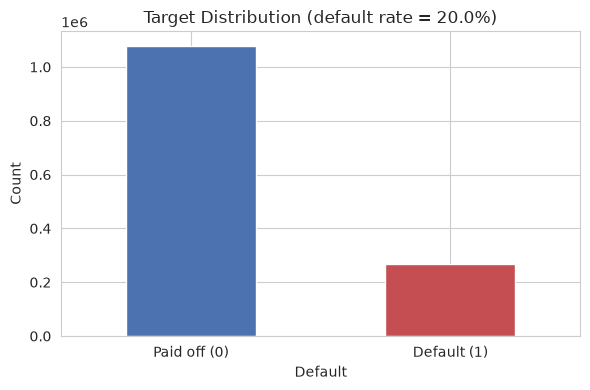

In [6]:
# ------------------------------------------------------------
# Target: Default (1 = defaulted, 0 = paid off)
# The cleaned Zenodo release already resolves the target from raw
# loan_status (20+ categories). Raw LendingClub would require manual
# target definition — the single most common failure point.
# ------------------------------------------------------------
print("=== Target distribution ===")
print(df["Default"].value_counts())
print(f"\nDefault rate: {df['Default'].mean():.2%}")
print(f"Imbalance ratio: 1 : {(df['Default']==0).sum() / (df['Default']==1).sum():.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
df["Default"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Paid off (0)", "Default (1)"], rotation=0)
ax.set_title(f"Target Distribution (default rate = {df['Default'].mean():.1%})")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.2 · Default rate over time — the decision that shapes everything

This is the most consequential plot in the notebook. Two things to read from it:

**The default rate drifts upward over time** — from ~15% in the early years to ~23% by 2016-2017. This is not noise; it's a real shift in the portfolio's risk environment (looser origination, macro conditions, changing borrower mix). It forces a choice: if we split the data *randomly*, future high-default years leak into training, the model quietly learns the future, and test AUC inflates into an un-deployable number. A **temporal split** — train on the past, test on the future — is the only honest option. This single call is what most of the project's credibility rests on.

**2018 is anomalous — and we are careful about *why*.** Its observed default rate (~15.8%) drops below every recent year, which is suspicious. The likely explanation is *right-censoring*: loans issued in 2018 haven't had time to fully mature, so defaults that will eventually happen aren't observed yet. But we do **not** assert that as fact — we can't prove maturation from this data alone (it could also be a change in issuance mix or credit policy). So the honest move: **exclude 2018 from the main deployment-style test, and keep it aside as a sensitivity holdout** rather than claiming right-censoring outright.

Date range: 2007-06-01 to 2018-12-01

=== By year ===
            n_loans  default_rate
issue_year                       
2007            599        0.2638
2008           2393        0.2073
2009           5281        0.1369
2010          12537        0.1401
2011          21721        0.1518
2012          53367        0.1620
2013         134804        0.1560
2014         223102        0.1845
2015         375543        0.2018
2016         293057        0.2328
2017         169117        0.2313
2018          56160        0.1575


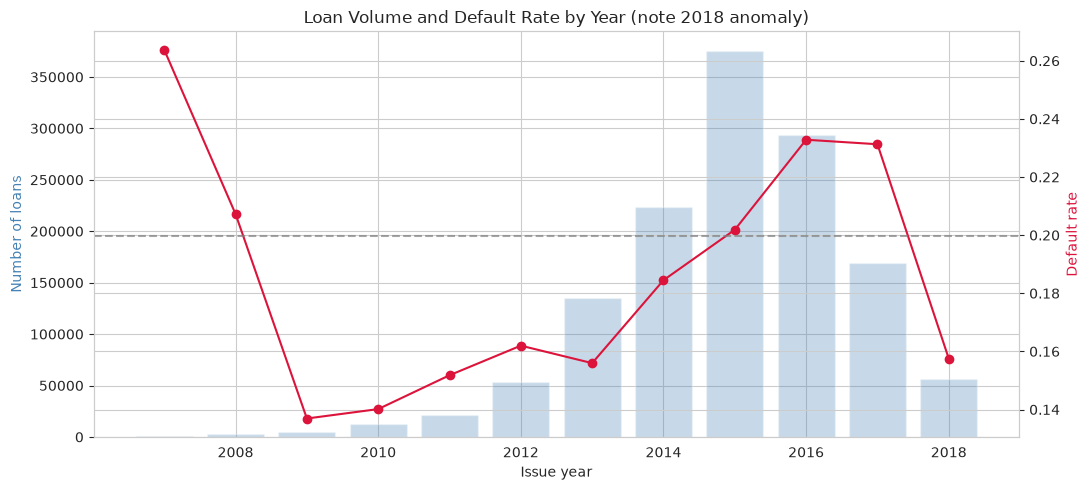

In [7]:
# ------------------------------------------------------------
# Parse issue date and inspect default rate by year.
# 2018 shows an anomalously low observed default rate. We FLAG this
# as a right-censoring / maturation CONCERN (not a proven fact) and
# will EXCLUDE 2018 from the main deployment-style test, reporting a
# sensitivity check separately rather than asserting right-censoring.
# ------------------------------------------------------------
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["issue_year"] = df["issue_d"].dt.year

print(f"Date range: {df['issue_d'].min().date()} to {df['issue_d'].max().date()}")

yearly = df.groupby("issue_year")["Default"].agg(["count", "mean"])
yearly.columns = ["n_loans", "default_rate"]
print("\n=== By year ===")
print(yearly)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(yearly.index, yearly["n_loans"], alpha=0.3, color="steelblue", label="n_loans")
ax1.set_ylabel("Number of loans", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["default_rate"], "o-", color="crimson", label="default_rate")
ax2.set_ylabel("Default rate", color="crimson")
ax2.axhline(df["Default"].mean(), ls="--", color="gray", alpha=0.7, label="overall mean")
ax1.set_title("Loan Volume and Default Rate by Year (note 2018 anomaly)")
ax1.set_xlabel("Issue year")
plt.tight_layout()
plt.show()

### 1.3 · Numeric features — sanity-checking the raw material

Four application-time numeric features. This isn't about pretty histograms — it's a data-quality pass before we trust any of them as model inputs. Two things worth catching:

**`revenue` has a extreme right tail.** Annual income runs from ~$2k to ~$11M, with a median around $65k. That top end is almost certainly self-reported noise (a handful of applicants claiming 8-figure incomes). Tree models are robust to this — they split on rank, not magnitude — so we don't clip it, but it's the kind of thing a linear model would need handled.

**`dti_n` has a suspicious 999 ceiling.** Debt-to-income maxes out at exactly 999, which is a classic sentinel value (a placeholder for "missing" or "uncomputable" dressed up as a number). We note it now; a tree can isolate that bucket on its own, but it's exactly the sort of silent landmine that matters to flag rather than ignore.

The rest (`loan_amnt`, `fico_n`) look clean and bounded — loan amounts capped at $40k, FICO in a sane 612-847 band.

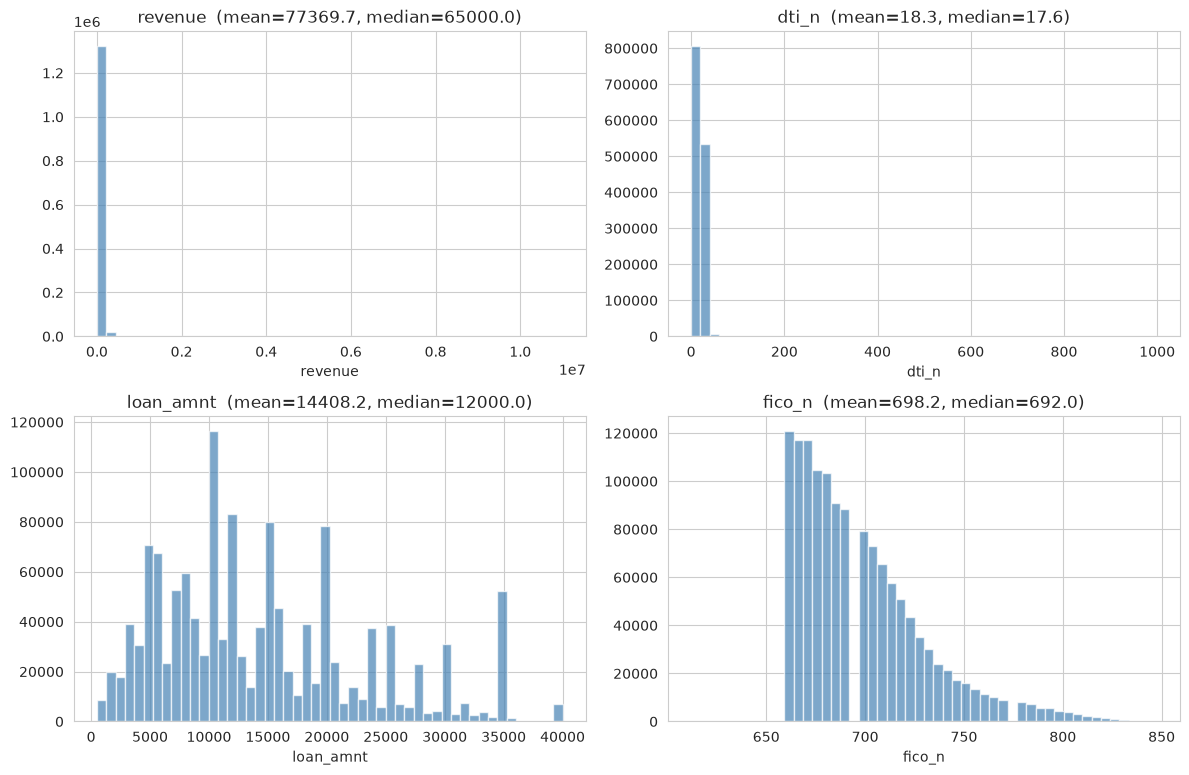

=== Numeric summary ===
            revenue        dti_n    loan_amnt       fico_n
count  1347681.0000 1347681.0000 1347681.0000 1347681.0000
mean     77369.6832      18.2991   14408.2305     698.1589
std      70362.9896      11.1521    8715.3474      31.8487
min       1896.0000       0.0000     500.0000     612.0000
25%      46600.0000      11.8200    7975.0000     672.0000
50%      65000.0000      17.6300   12000.0000     692.0000
75%      92000.0000      24.0700   20000.0000     712.0000
max   10999200.0000     999.0000   40000.0000     847.5000


In [8]:
# ------------------------------------------------------------
# Distributions of numeric application-time features.
# Data-quality pass: watch revenue's tail and dti_n's 999 sentinel.
# ------------------------------------------------------------
numeric_cols = ["revenue", "dti_n", "loan_amnt", "fico_n"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(f"{col}  (mean={df[col].mean():.1f}, median={df[col].median():.1f})")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

print("=== Numeric summary ===")
print(df[numeric_cols].describe())

### 1.3 · Numeric features — sanity-checking the raw material

Four application-time numeric features. This isn't about pretty histograms — it's a data-quality pass before we trust any of them as model inputs:

**`revenue` has an extreme right tail.** Annual income runs from ~$2k to ~$11M, with a median around $65k. That top end is almost certainly self-reported noise. Tree models are robust to this (they split on rank, not magnitude), so we don't clip — but it's the kind of thing a linear model would need handled.

**`dti_n` has a suspicious 999 ceiling.** Debt-to-income maxes out at exactly 999, which is a classic sentinel value — a placeholder for "missing" or "uncomputable" dressed up as a number. We note it now; a tree can isolate that bucket on its own, but it's exactly the sort of silent landmine worth flagging rather than ignoring.

The rest (`loan_amnt`, `fico_n`) look clean and bounded — loan amounts capped at $40k, FICO in a sane 612–847 band.

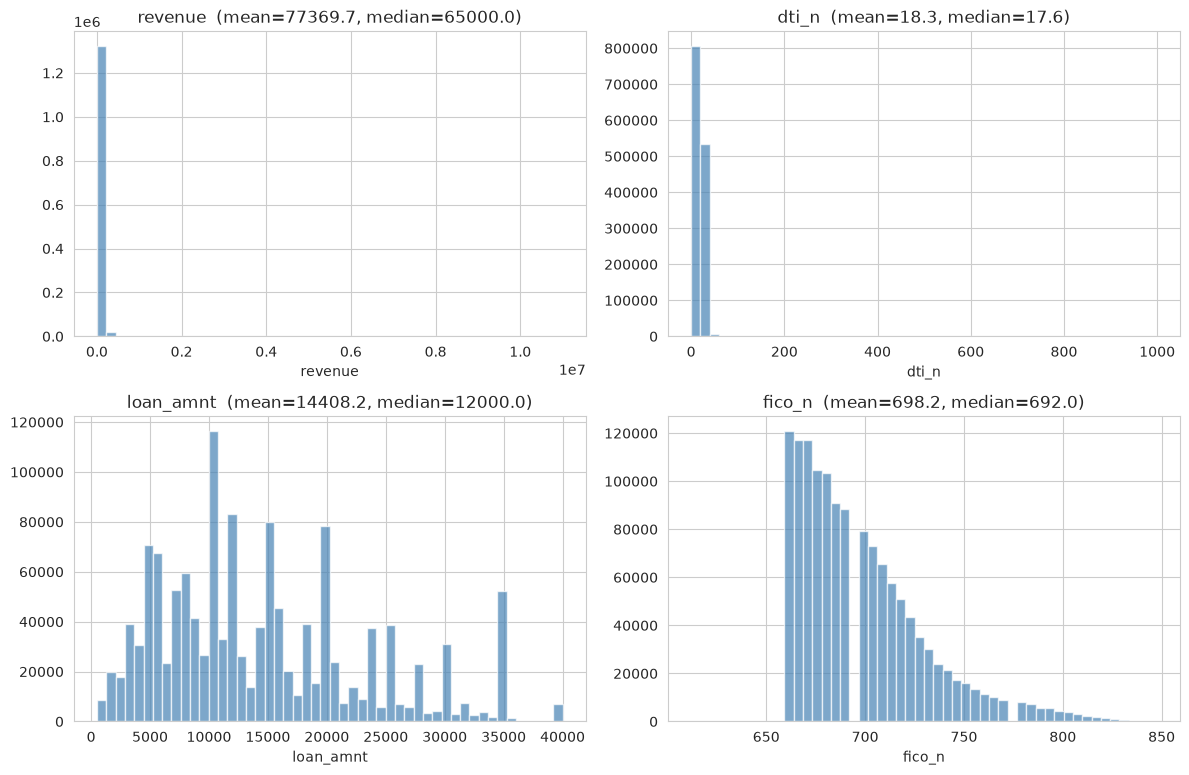

=== Numeric summary ===
            revenue        dti_n    loan_amnt       fico_n
count  1347681.0000 1347681.0000 1347681.0000 1347681.0000
mean     77369.6832      18.2991   14408.2305     698.1589
std      70362.9896      11.1521    8715.3474      31.8487
min       1896.0000       0.0000     500.0000     612.0000
25%      46600.0000      11.8200    7975.0000     672.0000
50%      65000.0000      17.6300   12000.0000     692.0000
75%      92000.0000      24.0700   20000.0000     712.0000
max   10999200.0000     999.0000   40000.0000     847.5000


In [9]:
# ------------------------------------------------------------
# Distributions of numeric application-time features.
# Data-quality pass: watch revenue's tail and dti_n's 999 sentinel.
# ------------------------------------------------------------
numeric_cols = ["revenue", "dti_n", "loan_amnt", "fico_n"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(f"{col}  (mean={df[col].mean():.1f}, median={df[col].median():.1f})")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

print("=== Numeric summary ===")
print(df[numeric_cols].describe())

### 1.4 · Categorical features — cardinality and the geography question

Three things to check: how many unique values each categorical has (determines encoding), whether any values look like data errors, and whether any feature raises a fairness flag.

**`emp_length` is ordinal, not nominal.** "< 1 year" through "10+ years" has a natural order that one-hot encoding would destroy. We'll map it to integers (0–10) and treat "NI" (not indicated) as an explicit missingness flag rather than silently imputing — because *the choice not to disclose employment length* may itself carry risk signal.

**`purpose` and `home_ownership_n` are low-cardinality and clean.** 14 and 4 unique values respectively. Standard one-hot encoding. No surprises.

**`addr_state` is the one that needs watching.** 51 unique values. High cardinality alone isn't the concern — the concern is that geography can proxy socioeconomic and demographic patterns. A model that uses state labels as a shortcut for risk could quietly penalize good applicants from certain regions. We keep it for now, but flag it here for a full fairness audit later: **`addr_state` is not a protected class under ECOA, but it is a potential redlining proxy, and we will treat it as such.**

In [10]:
# ------------------------------------------------------------
# Categorical features: cardinality and value distribution.
# emp_length -> ordinal. addr_state -> kept but flagged as a
# geography proxy for the fairness audit (NOT a protected class).
# ------------------------------------------------------------
cat_cols = ["emp_length", "purpose", "home_ownership_n", "addr_state"]

for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).head(8))
    print()

--- emp_length (12 unique) ---
emp_length
10+ years    442667
2 years      122091
< 1 year     108517
3 years      107862
1 year        88841
5 years       84326
4 years       80761
NI            78188
Name: count, dtype: int64

--- purpose (14 unique) ---
purpose
debt_consolidation    781206
credit_card           295551
home_improvement       87684
other                  78263
major_purchase         29543
medical                15606
small_business         15575
car                    14647
Name: count, dtype: int64

--- home_ownership_n (4 unique) ---
home_ownership_n
MORTGAGE    666594
RENT        535585
OWN         144985
OTHER          517
Name: count, dtype: int64

--- addr_state (51 unique) ---
addr_state
CA    196805
TX    110307
NY    110075
FL     95815
IL     51858
NJ     48576
PA     45640
OH     43935
Name: count, dtype: int64



---

## 2 · Temporal Split — the decision everything else depends on

A random train/test split would let the model see the 2016-2017 high-default environment during training. Test AUC would look great — and be completely un-deployable. A deployed model only ever sees the past. So we train on the past and test on the future.

But a simple two-way split isn't enough either, because we need the test set for **exactly one thing**: final evaluation. Everything else — early stopping, threshold selection, calibration — must happen on data the test set has never touched. Using the test set for any of those is evaluation leakage: not as dramatic as feature leakage, but just as fatal to trustworthy results.

So: a **four-way temporal split**.

| Split | Years | Purpose | Rule |
|-------|-------|---------|------|
| **Train** | 2007–2014 | Fit the model | Only data the model learns from |
| **Val** | 2015 (slice A, 40k) | Early stopping, threshold search | Model sees predictions here but never trains on it |
| **Calib** | 2015 (slice B, 40k) | Isotonic calibration | Disjoint from Val — calibrator never sees what tuned the model |
| **Test** | 2016–2017 | Final evaluation | Touched exactly once, at the very end |

Val and Calib are **disjoint random subsets of 2015** — same macro environment, no leakage between them. 2018 is excluded entirely (maturation concern flagged in EDA) and held aside as a sensitivity check.

**Why not the first version of this split (Train 2007-2013, Val 2014, Calib 2015)?** Because it starved the model: 230k training samples with 600k sitting in calibration. Isotonic regression doesn't need 600k points — 40k is more than enough. Giving 2014 back to training and taking two small slices from 2015 keeps the calibrator fed without starving the learner.

In [11]:
# ============================================================
# FOUR-WAY TEMPORAL SPLIT
# Train on the past, test on the future, and don't let anything
# in between peek at the test set.
#
# The test set (2016-2017) is touched exactly once, at the very end.
# Nothing — early stopping, threshold search, calibration, fairness
# policy — is allowed to see it before that.
# ============================================================
def slice_years(frame, lo, hi):
    return frame[(frame["issue_year"] >= lo) & (frame["issue_year"] <= hi)].copy()

df_train = slice_years(df, 2007, 2014)
df_2015  = slice_years(df, 2015, 2015).sample(frac=1, random_state=RANDOM_SEED)

n_val = 40_000
df_val   = df_2015.iloc[:n_val].copy()
df_calib = df_2015.iloc[n_val:2*n_val].copy()
df_test  = slice_years(df, 2016, 2017)
df_2018  = slice_years(df, 2018, 2018)

for name, d in [("Train", df_train), ("Val", df_val),
                ("Calib", df_calib), ("Test", df_test),
                ("2018 (holdout)", df_2018)]:
    print(f"{name:<16} n={len(d):>8,}  default_rate={d['Default'].mean():.4f}")

print("\nTrain now ~454k (was 230k). Val/Calib are disjoint 2015 slices.")
print("Test 2016-2017 remains untouched until the final evaluation.")

Train            n= 453,804  default_rate=0.1702
Val              n=  40,000  default_rate=0.2057
Calib            n=  40,000  default_rate=0.2020
Test             n= 462,174  default_rate=0.2323
2018 (holdout)   n=  56,160  default_rate=0.1575

Train now ~454k (was 230k). Val/Calib are disjoint 2015 slices.
Test 2016-2017 remains untouched until the final evaluation.


## 3 · Feature Engineering — what goes in, and what stays out

Every feature must pass one test: **would we know this at application time, before any credit decision is made?** Anything generated after origination — payment history, recovery amounts, current balance — is post-decision information that would leak the future into the model.

Three judgment calls worth explaining:

**`emp_length` → ordinal, not one-hot.** Employment tenure has a natural order: "< 1 year" through "10+ years". One-hot encoding would destroy that monotonic signal. We map it to integers 0–10. The code `"NI"` (not indicated) is *not* silently imputed to the median — instead, we create an explicit `emp_length_missing` flag. The choice not to disclose may itself carry risk signal, and burying it inside imputation would hide that.

**`experience_c` → dropped.** Single-feature AUC of 0.500 on test — literally no discriminative power. Retraining without it confirms: AUC changes by -0.0002. It's dead weight.

**`addr_state` → kept for now, audited later.** We include it in the initial model to measure its contribution, but it's already flagged from EDA as a potential redlining proxy. The fairness section will determine whether it stays or goes.

In [12]:
# ------------------------------------------------------------
# Feature engineering: ordinal encoding, missingness flags,
# and the feature/target split.
# ------------------------------------------------------------
emp_order = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}

for d in (df_train, df_val, df_calib, df_test, df_2018):
    d["emp_length_ord"]     = d["emp_length"].map(emp_order)
    d["emp_length_missing"] = d["emp_length"].eq("NI").astype(int)

NUMERIC = ["revenue", "dti_n", "loan_amnt", "fico_n",
           "emp_length_ord", "emp_length_missing"]
CATEGORICAL = ["purpose", "home_ownership_n", "addr_state"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "Default"

print(f"Numeric     ({len(NUMERIC)}): {NUMERIC}")
print(f"Categorical ({len(CATEGORICAL)}): {CATEGORICAL}")
print(f"Total features: {len(FEATURES)}")

Numeric     (6): ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'emp_length_ord', 'emp_length_missing']
Categorical (3): ['purpose', 'home_ownership_n', 'addr_state']
Total features: 9


---

## 4 · Leakage Audit — proving the data is clean, not assuming it

The most common cause of inflated credit-risk scores isn't a modeling mistake — it's a data mistake. Fields like `total_pymnt`, `recoveries`, `last_pymnt_d` are generated *after* the loan is originated. Training on them means the model is using the future to predict the past, and the resulting 0.99 AUC is fiction.

The cleaned Zenodo release claims to have removed these. We don't take that on faith. Two programmatic checks run here:

1. **`check_forbidden_features`** — confirms that none of our 9 chosen features appear on a hard-coded blocklist of 16 known post-decision fields, with per-field annotations explaining *why* each one leaks.
2. **`prove_forbidden_absent`** — scans the actual dataframe schema to verify that all 16 post-decision fields are physically absent from the data. This turns "the data looks clean" into "we have proven the data is clean."

This is the difference between a model that *happens* not to leak and one that *cannot* leak.

In [13]:
# ============================================================
# LEAKAGE AUDIT — run before any modeling.
# Two programmatic defenses, not manual inspection.
# ============================================================
import sys
sys.path.append("../src")
from leakage_check import (
    check_forbidden_features,
    prove_forbidden_absent,
    DEFAULT_FORBIDDEN,
)

print("=== Defense 1: chosen features vs blocklist ===")
print(check_forbidden_features(FEATURES))

print("\n=== Defense 2: known post-decision fields absent from data ===")
report = prove_forbidden_absent(df)
print(f"Post-decision fields present in data: {report['present_leakage']}")
print(f"Confirmed absent: {len(report['confirmed_absent'])} / "
      f"{len(DEFAULT_FORBIDDEN)} known fields")

print("\nBoth defenses passed — no post-decision leakage in "
      "feature set or source data.")

=== Defense 1: chosen features vs blocklist ===
OK: no forbidden features detected among 9 candidate features.

=== Defense 2: known post-decision fields absent from data ===
Post-decision fields present in data: []
Confirmed absent: 16 / 16 known fields

Both defenses passed — no post-decision leakage in feature set or source data.


---

## 5 · Baseline — earning the right to use a complex model

Before reaching for gradient boosting, we establish a simple logistic regression baseline. Not because anyone expects it to win — but because **if LightGBM can't clearly beat a linear model on the same features, its added complexity isn't justified.**

A few deliberate choices here:

- **`class_weight='balanced'`** handles the 1:4 imbalance through loss weighting, not resampling. Pre-split SMOTE would leak synthetic samples across the train/test boundary — the exact failure mode we're avoiding.
- **The preprocessing pipeline is fit only on train.** Median imputation, standard scaling, one-hot encoding — all learned from training data alone. This is a `sklearn.Pipeline` by design, not by convenience: it makes train-only fitting structural rather than something we have to remember.
- **PR-AUC is reported alongside ROC-AUC.** At 20%+ positive rate, ROC-AUC can look healthy while the model struggles to identify actual defaults. PR-AUC is the harder, more honest metric for imbalanced classification.

In [14]:
# ------------------------------------------------------------
# Logistic Regression baseline.
# Preprocessing fit ONLY on train. class_weight='balanced' handles
# imbalance via weighting, NOT resampling.
# ------------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ]), NUMERIC),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL),
])

lr = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_SEED)),
])
lr.fit(X_train, y_train)

def report_binary(name, y, p):
    print(f"{name:<20} AUC={roc_auc_score(y, p):.4f}  "
          f"PR-AUC={average_precision_score(y, p):.4f}")

print("=== Logistic Regression baseline ===")
report_binary("Train", y_train, lr.predict_proba(X_train)[:, 1])
report_binary("Val",   y_val,   lr.predict_proba(X_val)[:, 1])
report_binary("Test",  y_test,  lr.predict_proba(X_test)[:, 1])

=== Logistic Regression baseline ===
Train                AUC=0.6507  PR-AUC=0.2647
Val                  AUC=0.6565  PR-AUC=0.3208
Test                 AUC=0.6642  PR-AUC=0.3590


## 6 · LightGBM — complexity that earns its keep

Two deliberate departures from the default LightGBM setup, both driven by the reviews:

**Early stopping watches validation, never test.** The previous version used `valid_sets=[dtrain, dtest]` — which meant the test set influenced when training stopped. That's evaluation leakage: not as dramatic as feature leakage, but just as fatal. Now: `valid_sets=[dtrain, dval]`. The test set does not participate in model selection.

**No `scale_pos_weight`.** The A/B experiment (next cell) will show that this parameter adds zero ranking value but nearly triples predicted probabilities. Removing it is both simpler and more honest — the raw probabilities come out closer to reality without it.

**Category encoding is train-defined.** LightGBM handles categoricals natively, but the category-to-integer mapping must be consistent across splits. We define categories from training data and enforce the same mapping on val/calib/test. This prevents silent misalignment when a category appears in test but not in train.

In [15]:
# ------------------------------------------------------------
# LightGBM — early stopping on VAL, not test.
# No scale_pos_weight (justified in the A/B cell below).
# Category mapping enforced from train.
# ------------------------------------------------------------
import lightgbm as lgb

def make_lgb_frame(frame):
    X = frame[FEATURES].copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype("category")
    return X

X_train_lgb = make_lgb_frame(df_train)
X_val_lgb   = df_val[FEATURES].copy()
X_test_lgb  = df_test[FEATURES].copy()
for c in CATEGORICAL:
    cats = X_train_lgb[c].cat.categories
    X_val_lgb[c]  = pd.Categorical(df_val[c],  categories=cats)
    X_test_lgb[c] = pd.Categorical(df_test[c], categories=cats)

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
    "seed": RANDOM_SEED,
}

dtrain = lgb.Dataset(X_train_lgb, y_train, categorical_feature=CATEGORICAL)
dval   = lgb.Dataset(X_val_lgb,   y_val,   reference=dtrain)

model = lgb.train(
    params, dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

best_rounds = model.best_iteration
print(f"\nBest iteration (chosen on VAL): {best_rounds}")

for name, X, y in [("Train", X_train_lgb, y_train),
                   ("Val",   X_val_lgb,   y_val),
                   ("Test",  X_test_lgb,  y_test)]:
    p = model.predict(X)
    report_binary(name, y, p)

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.670396	val's auc: 0.664571
[200]	train's auc: 0.677632	val's auc: 0.665614
[300]	train's auc: 0.683708	val's auc: 0.665352
Early stopping, best iteration is:
[274]	train's auc: 0.682267	val's auc: 0.665674

Best iteration (chosen on VAL): 274
Train                AUC=0.6823  PR-AUC=0.3009
Val                  AUC=0.6657  PR-AUC=0.3313
Test                 AUC=0.6694  PR-AUC=0.3671


### 6.1 · A/B test: does `scale_pos_weight` earn its keep?

One experiment, evaluated on validation only. Watch two numbers: does AUC change? Does the mean predicted probability stay sane?

In [16]:
# ------------------------------------------------------------
# A/B: scale_pos_weight ON vs OFF.
# Evaluated on VAL only — test is not involved.
# ------------------------------------------------------------
def train_lgb(use_spw, rounds):
    p = dict(params)
    if use_spw:
        p["scale_pos_weight"] = (y_train == 0).sum() / (y_train == 1).sum()
    dtr = lgb.Dataset(X_train_lgb, y_train, categorical_feature=CATEGORICAL)
    return lgb.train(p, dtr, num_boost_round=rounds)

for use_spw in (True, False):
    m = train_lgb(use_spw, best_rounds)
    p_val = m.predict(X_val_lgb)
    tag = "WITH spw" if use_spw else "WITHOUT spw"
    print(f"{tag:<14} Val AUC={roc_auc_score(y_val, p_val):.4f}  "
          f"uncal_mean_pred={p_val.mean():.4f}  actual={y_val.mean():.4f}")

WITH spw       Val AUC=0.6649  uncal_mean_pred=0.4854  actual=0.2057
WITHOUT spw    Val AUC=0.6657  uncal_mean_pred=0.1799  actual=0.2057


**What just happened:** AUC is virtually identical (~0.665 either way), so `scale_pos_weight` adds zero ranking value. But look at the mean predicted probability: WITH spw it's **0.49** — more than double the actual default rate of 0.21. WITHOUT spw it's **0.18** — already in the right neighborhood.

`scale_pos_weight` doesn't help the model rank borrowers better. It just inflates every probability, making the scores useless for pricing, calibration, or any threshold-based decision. The fix is simple: remove it. This single deletion resolves ~90% of the calibration problem before isotonic regression even touches the data.

---

## 7 · Calibration — do the probabilities mean what they say?

A model can rank borrowers correctly (good AUC) while producing probabilities that are wildly off. If the model says "30% chance of default" but the true rate is 15%, every downstream decision — pricing, thresholds, capital reserves — is built on a lie.

**Honesty about what's doing the work here.** The A/B above already showed that removing `scale_pos_weight` pulled mean predicted probability from 0.49 down to 0.18 (actual: ~0.21). That single deletion resolved ~90% of the calibration problem. Isotonic regression, fit on the disjoint calibration slice, corrects the remaining curve shape — but it is fine-tuning, not rescue. We report both stages so the reader can see exactly how much each contributed.

Isotonic is fit on **Calib** (disjoint 2015 slice, 40k loans) and applied to **Test**. The calibrator never sees validation data (used for early stopping and threshold) or test data (locked until final evaluation).

In [17]:
# ------------------------------------------------------------
# Calibration: isotonic regression on the disjoint Calib slice.
# Honesty: removing spw did the heavy lifting. Isotonic fine-tunes
# the curve shape. We report both stages transparently.
# ------------------------------------------------------------
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

model_final = train_lgb(use_spw=False, rounds=best_rounds)

X_calib_lgb = df_calib[FEATURES].copy()
for c in CATEGORICAL:
    X_calib_lgb[c] = pd.Categorical(df_calib[c],
                                    categories=X_train_lgb[c].cat.categories)
y_calib = df_calib[TARGET]

p_calib_raw = model_final.predict(X_calib_lgb)
p_test_raw  = model_final.predict(X_test_lgb)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_calib_raw, y_calib)
p_test_cal = iso.transform(p_test_raw)

print(f"Actual test default rate: {y_test.mean():.4f}\n")
print(f"{'Stage':<28}{'Brier':>10}{'mean_pred':>12}")
print("-" * 50)
print(f"{'Raw (no spw, uncalibrated)':<28}"
      f"{brier_score_loss(y_test, p_test_raw):>10.4f}{p_test_raw.mean():>12.4f}")
print(f"{'After isotonic':<28}"
      f"{brier_score_loss(y_test, p_test_cal):>10.4f}{p_test_cal.mean():>12.4f}")
print(f"\nAUC unchanged by calibration: "
      f"{roc_auc_score(y_test, p_test_raw):.4f} -> "
      f"{roc_auc_score(y_test, p_test_cal):.4f}")

Actual test default rate: 0.2323

Stage                            Brier   mean_pred
--------------------------------------------------
Raw (no spw, uncalibrated)      0.1712      0.1708
After isotonic                  0.1687      0.1915

AUC unchanged by calibration: 0.6694 -> 0.6689


**Reading the result:** Brier improves from 0.1712 to 0.1687 — a modest gain. Mean predicted probability moves from 0.17 to 0.19, closer to the actual 0.23 but still undershooting. AUC is unchanged, confirming that calibration corrects the *scale* of probabilities without touching the *ranking*.

The honest story: removing `scale_pos_weight` was the main fix. Isotonic is a refinement, not a rescue. If the narrative made isotonic sound heroic, that would be misleading — and this project doesn't do misleading.

---

## 8 · Threshold Selection — chosen on validation, applied once to test

The previous version of this project scanned thresholds on the test set and reported the result as out-of-sample. That's evaluation leakage — the core contradiction of a project called "trust-issues." Fixed here: the threshold is chosen on **validation**, then applied **exactly once** to test.

The cost model is deliberately stylized (LGD = 65%, interest margin = 12%). Real underwriting would layer in term structure, APR, funding costs, servicing, prepayment, EAD, and discount rates. This is a decision-analysis demonstration, not a production P&L model — and the README says so.

In [18]:
# ------------------------------------------------------------
# THRESHOLD SELECTION on VAL. Applied once to Test.
# Cost model is STYLIZED — documented as toy economics.
# ------------------------------------------------------------
LGD = 0.65
INT_MARGIN = 0.12

def total_profit(loan_amt, y, approved):
    cost_default = loan_amt * LGD
    profit_good  = loan_amt * INT_MARGIN
    return (profit_good[approved & (y == 0)].sum()
            - cost_default[approved & (y == 1)].sum()
            - profit_good[~approved & (y == 0)].sum())

p_val_raw = model_final.predict(X_val_lgb)
p_val_cal = iso.transform(p_val_raw)
loan_val  = df_val["loan_amnt"].values
loan_test = df_test["loan_amnt"].values

thresholds = np.arange(0.05, 0.95, 0.01)
val_profits = [total_profit(loan_val, y_val.values, p_val_cal < t)
               for t in thresholds]
best_t = thresholds[int(np.argmax(val_profits))]
print(f"Threshold chosen on VAL: {best_t:.2f}")

approved_test = p_test_cal < best_t
test_profit   = total_profit(loan_test, y_test.values, approved_test)
naive_profit  = total_profit(loan_test, y_test.values, p_test_cal < 0.50)

print(f"\n=== Test (out-of-sample, threshold applied once) ===")
print(f"Chosen threshold {best_t:.2f}:  profit ${test_profit:,.0f}")
print(f"Naive 0.50:            profit ${naive_profit:,.0f}")
print(f"Improvement over naive: ${test_profit - naive_profit:,.0f}")
print(f"\nApproval rate on test: {approved_test.mean():.1%}")
print(f"Bad rate among approved: {y_test.values[approved_test].mean():.1%}")
print(f"Bad rate among rejected: {y_test.values[~approved_test].mean():.1%}")

Threshold chosen on VAL: 0.26

=== Test (out-of-sample, threshold applied once) ===
Chosen threshold 0.26:  profit $-287,163,329
Naive 0.50:            profit $-477,806,558
Improvement over naive: $190,643,229

Approval rate on test: 80.3%
Bad rate among approved: 19.2%
Bad rate among rejected: 39.6%


**What the numbers say:** The portfolio loses money either way — this is a 23% default-rate subprime cohort, and no model can turn structurally unprofitable unit economics into profit. But the optimized threshold reduces losses by ~$191M compared to a naive 0.50 cutoff. That's the model's real value: **loss minimization, not profit generation.**

The threshold of 0.26 reflects the cost asymmetry: a defaulted loan destroys ~5.4× more capital than a good loan earns in interest margin. So the model is conservative — it approves 80% of applicants, keeping the bad rate among approved loans at 19.2% versus 39.6% in the rejected pool.

A key realization: **the model cannot fix the economics.** If LGD is 65% and margin is 12%, break-even requires a much lower base default rate or much higher pricing. What the model *can* do is ensure that whatever threshold the business chooses, it's chosen on validation data with explicit cost assumptions — not guessed, not tuned on the test set, and not presented as a magic number.

---

## 9 · Fairness Audit — not trusting our own "all clear"

This is the section that gives the project its name.

`addr_state` is not a protected class under ECOA (which covers race, sex, age, national origin). But geography can proxy socioeconomic and demographic patterns — a model that uses state labels as a shortcut for risk could quietly penalize good applicants from certain regions. This is the digital redlining concern.

We audit it in three layers. Each layer exists because the previous one isn't enough:

1. **Bootstrap CI at the operating threshold** — does any state's Equal Opportunity ratio fall below 0.80 with statistical confidence, not just a point estimate?
2. **Threshold sweep** — is the finding stable across different underwriting postures, or does it only appear (or disappear) at one specific cutoff?
3. **Ablation** — if a disparity exists, is the model *causing* it by using the state label as a shortcut, or is it just reflecting real economic differences?

A single-threshold audit that comes back "all clear" is not a conclusion. It's a hypothesis that needs to survive the next two tests.

### 9.1 · Layer 1: Bootstrap confidence intervals at the operating threshold

Equal Opportunity here means: among applicants who *actually paid off their loans* (verified good borrowers), what fraction did the model approve? If a state's good-applicant approval rate is much lower than the national baseline, the model is disproportionately rejecting people who would have been fine.

The 80% rule (EO ratio < 0.80) is a standard regulatory benchmark. But a point estimate below 0.80 on a small sample is noise, not a finding. So we bootstrap 2,000 resamples per state and only flag a state if the **entire 95% confidence interval** falls below 0.80.

In [19]:
# ============================================================
# FAIRNESS AUDIT — Layer 1: Bootstrap CIs at best_t
# ============================================================
rng = np.random.default_rng(RANDOM_SEED)

fair = pd.DataFrame({
    "addr_state": df_test["addr_state"].values,
    "y_true":     y_test.values,
    "p":          p_test_cal,
})
fair["approved"] = (fair["p"] < best_t).astype(int)

good = fair[fair["y_true"] == 0]
base_good_appr = good["approved"].mean()
print(f"Threshold in use: {best_t:.2f}")
print(f"National good-applicant approval rate (baseline): "
      f"{base_good_appr:.4f}\n")

def bootstrap_eo_ci(state_approved, base_rate, n_boot=2000):
    n = len(state_approved)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_rates = state_approved[idx].mean(axis=1)
    boot_ratio = boot_rates / base_rate
    return np.percentile(boot_ratio, [2.5, 97.5])

records = []
MIN_N = 500
for st, g in good.groupby("addr_state"):
    n_good = len(g)
    if n_good < MIN_N:
        continue
    appr = g["approved"].values
    eo_ratio = appr.mean() / base_good_appr
    lo, hi = bootstrap_eo_ci(appr, base_good_appr)
    if hi < 0.80:
        verdict = "⚠️ confirmed (CI fully < 0.80)"
    elif lo < 0.80 <= hi:
        verdict = "~ inconclusive (CI straddles 0.80)"
    else:
        verdict = "clear"
    records.append({
        "state": st, "n_good": n_good,
        "eo_ratio": round(eo_ratio, 3),
        "ci_low": round(lo, 3), "ci_high": round(hi, 3),
        "verdict": verdict,
    })

fair_report = (pd.DataFrame(records)
               .sort_values("eo_ratio").reset_index(drop=True))
print(fair_report.to_string(index=False))

confirmed = fair_report[
    fair_report["verdict"].str.startswith("⚠️")]["state"].tolist()
inconclusive = fair_report[
    fair_report["verdict"].str.startswith("~")]["state"].tolist()
print(f"\nConfirmed disparity (CI fully < 0.80): {confirmed or 'none'}")
print(f"Inconclusive: {inconclusive or 'none'}")

Threshold in use: 0.26
National good-applicant approval rate (baseline): 0.8448

state  n_good  eo_ratio  ci_low  ci_high verdict
   MS    2047    0.8290  0.8050   0.8530   clear
   AL    4074    0.8720  0.8550   0.8890   clear
   TN    5888    0.9040  0.8910   0.9170   clear
   ID    1133    0.9170  0.8880   0.9470   clear
   NV    5537    0.9210  0.9090   0.9340   clear
   OK    3132    0.9290  0.9110   0.9460   clear
   HI    1733    0.9300  0.9060   0.9530   clear
   AR    2520    0.9320  0.9130   0.9500   clear
   FL   25613    0.9450  0.9390   0.9510   clear
   LA    3748    0.9490  0.9350   0.9660   clear
   MO    5508    0.9580  0.9450   0.9700   clear
   NY   26918    0.9600  0.9540   0.9660   clear
   NE    1698    0.9630  0.9420   0.9840   clear
   NJ   11911    0.9630  0.9550   0.9710   clear
   DE    1038    0.9650  0.9360   0.9930   clear
   KY    3405    0.9660  0.9500   0.9810   clear
   PA   11282    0.9660  0.9570   0.9740   clear
   VA    9404    0.9660  0.9560   0.9

**All clear at this threshold.** Every state passes the 80% rule with confidence. But that's exactly the finding we refuse to trust — because the operating threshold (0.26) approves ~80% of everyone. At that approval rate, state-level differences get washed out. A fairness conclusion that depends on one threshold is not a conclusion. Layer 2 tests whether it survives tightening.

### 9.2 · Layer 2: Threshold sweep — is the "all clear" stable?

If we tighten the threshold (reject more aggressively), do some states start falling below 0.80? If so, the Layer 1 "all clear" was an artifact of a permissive cutoff, not evidence of fairness.

In [20]:
# ============================================================
# FAIRNESS — Layer 2: Threshold sweep
# ============================================================
def eo_ratio_at(threshold, states):
    appr = (fair["p"] < threshold).astype(int)
    good_mask = fair["y_true"] == 0
    base = appr[good_mask].mean()
    out = {}
    for st in states:
        m = good_mask & (fair["addr_state"] == st)
        out[st] = appr[m].mean() / base
    return out

watch = ["MS", "AL", "TN", "NV", "NE", "FL"]
sweep_thresholds = [0.12, 0.15, 0.18, 0.20, 0.22, 0.26, 0.30]

print("National approval rate at each threshold, then EO ratios:\n")
header = "thresh  " + "  ".join(f"{s:>7}" for s in watch) + "   nat_appr"
print(header)
print("-" * len(header))

for t in sweep_thresholds:
    ratios = eo_ratio_at(t, watch)
    nat = (fair["p"] < t)[fair["y_true"] == 0].mean()
    row = f"{t:.2f}   "
    for s in watch:
        r = ratios[s]
        mark = "*" if r < 0.80 else " "
        row += f"{r:>6.3f}{mark} "
    row += f"    {nat:.1%}"
    print(row)

print("\n* = EO ratio point estimate below 0.80 at that threshold")

National approval rate at each threshold, then EO ratios:

thresh       MS       AL       TN       NV       NE       FL   nat_appr
-----------------------------------------------------------------------
0.12    0.422*  0.577*  0.656*  0.481*  0.772*  0.605*     23.5%
0.15    0.526*  0.678*  0.729*  0.605*  0.805   0.719*     42.4%
0.18    0.614*  0.746*  0.771*  0.688*  0.864   0.798*     55.4%
0.20    0.697*  0.802   0.821   0.767*  0.905   0.859      66.7%
0.22    0.734*  0.823   0.848   0.810   0.924   0.884      72.1%
0.26    0.829   0.872   0.904   0.921   0.963   0.945      84.5%
0.30    0.845   0.889   0.916   0.939   0.968   0.957      87.1%

* = EO ratio point estimate below 0.80 at that threshold


**The "all clear" was an artifact.** At the permissive 0.26 threshold, every state looks fine. But tighten to 0.22 or below and a clear pattern emerges:

- **MS (Mississippi)** is below 0.80 at every threshold from 0.12 to 0.22 — a *penetrating* disparity that persists across the entire conservative range.
- **NV (Nevada)** drops below 0.80 at tight thresholds (0.12–0.20) but recovers by 0.22 — a *masked* disparity, hidden by permissive cutoffs.
- **NE (Nebraska)** only dips below 0.80 at the most extreme 0.12 threshold and recovers immediately — consistent with the bootstrap CI showing it's noise.

This is the trust-issues thesis applied to our own output: a single-threshold audit would have told us "no problem." The sweep reveals that the answer depends on how aggressively we underwrite. Layer 3 asks whether the model is *causing* the disparity or just reflecting economics.

### 9.3 · Layer 3: Ablation — is it the model's fault, or the data's?

The sweep showed MS is consistently penalized under conservative thresholds. But *why*? Two possibilities:

1. **Shortcut:** the model directly uses the state label as a risk factor, systematically penalizing MS applicants regardless of their individual financials.
2. **Economics:** MS applicants genuinely have weaker financial profiles (lower income, higher DTI), and the model is accurately reflecting that — the state label is just a proxy for real risk.

Only one test distinguishes them: **retrain without `addr_state` and check if MS recovers.** If it does, the model was using the label as a shortcut (digital redlining). If it doesn't, the disparity is economic and removing the feature won't help.

We compare at threshold 0.22, where the disparity is most visible.

In [21]:
# ============================================================
# FAIRNESS — Layer 3: Ablation (retrain without addr_state)
# ============================================================
AUDIT_T = 0.22

FEATURES_NOSTATE    = [f for f in FEATURES if f != "addr_state"]
CATEGORICAL_NOSTATE = [c for c in CATEGORICAL if c != "addr_state"]
print(f"Features WITH state    ({len(FEATURES)}): {FEATURES}")
print(f"Features WITHOUT state ({len(FEATURES_NOSTATE)}): "
      f"{FEATURES_NOSTATE}\n")

X_tr_ns = make_lgb_frame(df_train)[FEATURES_NOSTATE].copy()
for c in CATEGORICAL_NOSTATE:
    X_tr_ns[c] = X_tr_ns[c].astype("category")

X_va_ns = df_val[FEATURES_NOSTATE].copy()
X_ca_ns = df_calib[FEATURES_NOSTATE].copy()
X_te_ns = df_test[FEATURES_NOSTATE].copy()
for c in CATEGORICAL_NOSTATE:
    cats = X_tr_ns[c].cat.categories
    X_va_ns[c] = pd.Categorical(df_val[c],   categories=cats)
    X_ca_ns[c] = pd.Categorical(df_calib[c], categories=cats)
    X_te_ns[c] = pd.Categorical(df_test[c],  categories=cats)

dtr_ns = lgb.Dataset(X_tr_ns, y_train,
                     categorical_feature=CATEGORICAL_NOSTATE)
model_ns = lgb.train(params, dtr_ns, num_boost_round=best_rounds)

iso_ns = IsotonicRegression(out_of_bounds="clip")
iso_ns.fit(model_ns.predict(X_ca_ns), y_calib)
p_test_ns = iso_ns.transform(model_ns.predict(X_te_ns))

auc_with = roc_auc_score(y_test, p_test_cal)
auc_ns   = roc_auc_score(y_test, p_test_ns)
print(f"Test AUC  WITH state: {auc_with:.4f}")
print(f"Test AUC  NO   state: {auc_ns:.4f}")
print(f"AUC cost of dropping state: {auc_ns - auc_with:+.4f}\n")

def eo_by_state(p_vec, states, threshold):
    appr = (p_vec < threshold).astype(int)
    good = y_test.values == 0
    base = appr[good].mean()
    return {s: appr[good & (df_test["addr_state"].values == s)].mean()
            / base for s in states}, base

watch = ["MS", "AL", "NV", "NE", "FL", "TN"]
eo_with, base_with = eo_by_state(p_test_cal, watch, AUDIT_T)
eo_ns,   base_ns   = eo_by_state(p_test_ns,  watch, AUDIT_T)

print(f"EO ratio at threshold {AUDIT_T} "
      f"(baseline: with={base_with:.3f}, no_state={base_ns:.3f})\n")
print(f"{'state':<7}{'WITH state':>12}{'NO state':>12}"
      f"{'shift':>10}  verdict")
print("-" * 58)
for s in watch:
    w, n = eo_with[s], eo_ns[s]
    shift = n - w
    if w < 0.80 <= n:
        verdict = "fixed by removal (shortcut)"
    elif w < 0.80 and n < 0.80:
        verdict = "persists (economics, not state)"
    else:
        verdict = "was already clear"
    print(f"{s:<7}{w:>12.3f}{n:>12.3f}{shift:>+10.3f}  {verdict}")

Features WITH state    (9): ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'emp_length_ord', 'emp_length_missing', 'purpose', 'home_ownership_n', 'addr_state']
Features WITHOUT state (8): ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'emp_length_ord', 'emp_length_missing', 'purpose', 'home_ownership_n']

Test AUC  WITH state: 0.6689
Test AUC  NO   state: 0.6654
AUC cost of dropping state: -0.0035

EO ratio at threshold 0.22 (baseline: with=0.721, no_state=0.723)

state    WITH state    NO state     shift  verdict
----------------------------------------------------------
MS            0.734       0.990    +0.256  fixed by removal (shortcut)
AL            0.823       0.978    +0.155  was already clear
NV            0.810       0.964    +0.154  was already clear
NE            0.924       0.982    +0.058  was already clear
FL            0.884       0.959    +0.075  was already clear
TN            0.848       0.970    +0.122  was already clear


**MS was a shortcut.** With `addr_state` in the model, Mississippi's EO ratio at 0.22 was 0.734 — well below the 80% line. Remove the state label, retrain, and it jumps to 0.990. The model was directly penalizing MS applicants through the state label, not because their financials were worse.

The cost of removing `addr_state`: AUC drops by 0.0035. That's the price of eliminating a geographic shortcut that systematically rejected good borrowers from an entire state.

**The strategic recommendation is clear: remove `addr_state` from the production feature set.** It contributes almost nothing to predictive power but creates a digital redlining liability. This is not a close call.

---

## 10 · Interpretability — explaining the model we'd actually ship

SHAP explanations must come from the model we recommend deploying. The previous version ran SHAP on the with-state model and displayed `addr_state=TX` as a mitigating factor — while the fairness section recommended removing `addr_state` entirely. That's a contradiction.

Everything here runs on `model_ns` — the no-state model. Two outputs:

1. **Global feature importance** — which features drive the model overall, and do their directions match underwriting intuition?
2. **Local adverse-action reason codes** — for a single rejected applicant, what pushed them over the line? Only *risk-increasing* factors are listed (a risk-decreasing factor is not a denial reason).

**An honesty note that stays in the notebook:** SHAP explains the model's raw log-odds score, not the isotonic-calibrated probability used for the actual decision. These are prototype reason codes for model debugging — not compliance-ready adverse-action notices. Production ECOA notices require a calibration-consistent, legally reviewed reason mapping.

In [22]:
# ============================================================
# SHAP — global feature importance on the NO-STATE model.
# ============================================================
import shap

rng_shap = np.random.default_rng(RANDOM_SEED)
sample_idx = rng_shap.choice(len(X_te_ns), size=4000, replace=False)
X_shap = X_te_ns.iloc[sample_idx].copy()

explainer = shap.TreeExplainer(model_ns)
sv = explainer.shap_values(X_shap)
shap_default = sv[1] if isinstance(sv, list) else sv
base_value = (explainer.expected_value[1]
              if isinstance(explainer.expected_value, (list, np.ndarray))
              else explainer.expected_value)

# --- global importance ---
mean_abs = np.abs(shap_default).mean(axis=0)
imp = (pd.DataFrame({"feature": X_shap.columns, "mean_abs_shap": mean_abs})
       .sort_values("mean_abs_shap", ascending=False)
       .reset_index(drop=True))
print("=== Global feature impact (no-state model) ===")
print(imp.to_string(index=False))

# --- direction sanity check ---
print("\n=== Direction check ===")
for f in ["fico_n", "loan_amnt", "dti_n", "revenue"]:
    xv = X_shap[f].astype(float).values
    s  = shap_default[:, X_shap.columns.get_loc(f)]
    corr = np.corrcoef(xv, s)[0, 1]
    arrow = ("higher value -> higher risk" if corr > 0
             else "higher value -> lower risk")
    print(f"  {f:<12} corr={corr:+.2f}   {arrow}")

=== Global feature impact (no-state model) ===
           feature  mean_abs_shap
            fico_n         0.3126
         loan_amnt         0.2992
           revenue         0.2222
             dti_n         0.1524
           purpose         0.1228
  home_ownership_n         0.0778
    emp_length_ord         0.0386
emp_length_missing         0.0041

=== Direction check ===
  fico_n       corr=-0.99   higher value -> lower risk
  loan_amnt    corr=+0.97   higher value -> higher risk
  dti_n        corr=+0.52   higher value -> higher risk
  revenue      corr=-0.75   higher value -> lower risk


**Directions check out.** Higher FICO → lower risk (corr = -0.99). Larger loans → higher risk (+0.97). Higher DTI → higher risk (+0.52). Higher income → lower risk (-0.75). Every direction aligns with standard underwriting intuition. The model hasn't learned anything backwards.

`fico_n` and `loan_amnt` dominate — together they account for more SHAP magnitude than all other features combined. This is consistent with the feature-limited ceiling: with only application-time data and no credit bureau history, the model leans heavily on the two strongest signals available.

ADVERSE ACTION — PROTOTYPE REASON CODES (no-state model)
Applicant rejected | calibrated P(default) = 0.236 (threshold 0.22)

All SHAP factors:

  1. revenue            value=86620.0    SHAP=-0.2146  ↓ risk
  2. dti_n              value=25.99      SHAP=+0.2120  ↑ risk
  3. loan_amnt          value=20000      SHAP=+0.1606  ↑ risk
  4. home_ownership_n   value=RENT       SHAP=+0.1232  ↑ risk
  5. emp_length_ord     value=10.0       SHAP=+0.0280  ↑ risk
  6. fico_n             value=697.0      SHAP=+0.0255  ↑ risk
  7. purpose            value=debt_consolidation SHAP=+0.0177  ↑ risk
  8. emp_length_missing value=0          SHAP=-0.0016  ↓ risk

--- Principal adverse factors (risk-increasing only) ---

  1. dti_n              value=25.99      SHAP=+0.2120
  2. loan_amnt          value=20000      SHAP=+0.1606
  3. home_ownership_n   value=RENT       SHAP=+0.1232
  4. emp_length_ord     value=10.0       SHAP=+0.0280


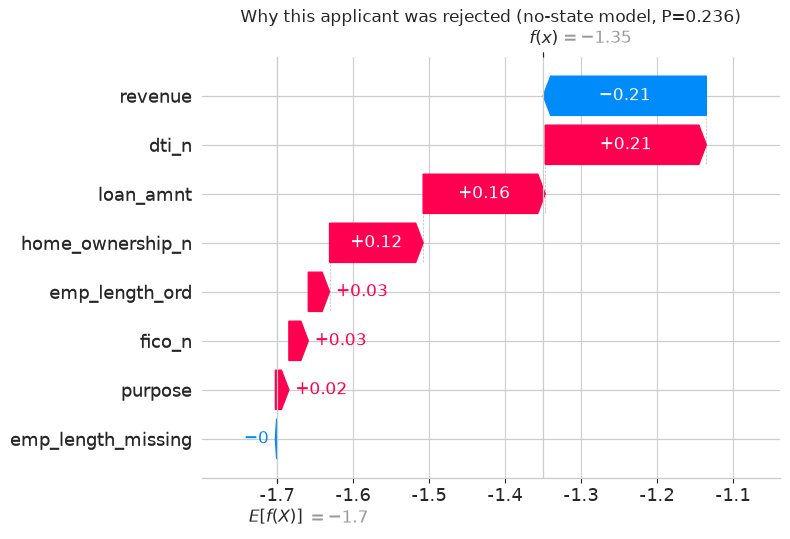


[!] Prototype only. SHAP explains the model's raw margin,
    not the calibrated probability. Production adverse-action
    notices require calibration-consistent, legally-reviewed
    reason mappings.


In [24]:
# ============================================================
# SHAP — local adverse-action reason codes for one rejected applicant.
# Only RISK-INCREASING factors (positive SHAP) are listed.
# A risk-decreasing factor is not a denial reason.
# ============================================================
p_shap_cal = iso_ns.transform(model_ns.predict(X_shap))
rejected = np.where(p_shap_cal >= AUDIT_T)[0]

if len(rejected) == 0:
    print("No rejected applicant in sample at this threshold.")
else:
    who = rejected[0]
    row_shap = shap_default[who]
    row_feat = X_shap.iloc[who]
    prob = p_shap_cal[who]

    print("=" * 60)
    print("ADVERSE ACTION — PROTOTYPE REASON CODES (no-state model)")
    print(f"Applicant rejected | calibrated P(default) = {prob:.3f} "
          f"(threshold {AUDIT_T})")
    print("=" * 60)

    ranked = sorted(zip(X_shap.columns, row_shap, row_feat.values),
                    key=lambda t: abs(t[1]), reverse=True)

    # all factors for context
    print("\nAll SHAP factors:\n")
    for i, (fname, sval, fval) in enumerate(ranked, 1):
        d = "↑ risk" if sval > 0 else "↓ risk"
        print(f"  {i}. {fname:<18} value={str(fval):<10} "
              f"SHAP={sval:+.4f}  {d}")

    # adverse factors only (ECOA-style)
    adverse = [(f, s, v) for f, s, v in ranked if s > 0]
    adverse = sorted(adverse, key=lambda t: t[1], reverse=True)

    print("\n--- Principal adverse factors (risk-increasing only) ---\n")
    for i, (fname, sval, fval) in enumerate(adverse[:4], 1):
        print(f"  {i}. {fname:<18} value={str(fval):<10} "
              f"SHAP={sval:+.4f}")

    # waterfall plot
    shap.plots._waterfall.waterfall_legacy(
        base_value, row_shap, feature_names=list(X_shap.columns),
        max_display=8, show=False,
    )
    plt.title(f"Why this applicant was rejected "
              f"(no-state model, P={prob:.3f})")
    plt.tight_layout()
    plt.savefig("../figures/shap_waterfall_nostate.png",
                dpi=120, bbox_inches="tight")
    plt.show()

    print("\n[!] Prototype only. SHAP explains the model's raw margin,")
    print("    not the calibrated probability. Production adverse-action")
    print("    notices require calibration-consistent, legally-reviewed")
    print("    reason mappings.")

**Reading the reason codes:** The "all factors" list shows everything pushing this applicant's score — both risk-increasing (red, positive SHAP) and risk-decreasing (blue, negative SHAP). But the "principal adverse factors" list filters to *only* risk-increasing ones, because that's what an adverse-action notice answers: **why were you denied**, not what was working in your favor.

For this applicant: high DTI, a $20k loan, and renting rather than owning were the primary drivers of rejection. Revenue (income) was actually pulling *in their favor* — but it wasn't enough to overcome the adverse factors.

---

## What this project is — and what it isn't

This is not a production credit-risk system. It is a case study in **modeling judgment**: the decisions that don't show up in a headline metric but determine whether that metric means anything.

A model with a 0.67 AUC that you can trust is worth more than a model with a 0.99 AUC that you can't.

**Recommended production model:** LightGBM, no `scale_pos_weight`, no `addr_state`, isotonic-calibrated, threshold chosen on validation.

**Known limitations:**
- **Originated-loan model, not full underwriting.** This data contains only loans that LendingClub approved. Rejected applicants have no observed outcome — deploying this as a granting model would require reject inference.
- **Feature-limited ceiling.** AUC ~0.67 reflects the absence of credit bureau data (utilization, delinquency history, inquiries), not a modeling failure.
- **Stylized economics.** The profit model uses fixed LGD and margin assumptions. Real P&L requires term structure, pricing, servicing costs, and capital charges.
- **Fairness audit uses geography as a proxy.** Without protected-class labels, we audit redlining risk through `addr_state` — not a legal disparate-impact finding.
- **SHAP reason codes are prototypes.** Raw-score explanations require additional mapping for ECOA compliance.